# Notebook 4 - Beyond the Surface Code: qLDPC & Bivariate-Bicycle Codes

*Part of **QEC Explorer**. Notebooks 1-3 built the surface code and showed both its power and its costs: it needs **large distances** for clean protection, and large distance means **a lot of physical qubits per logical qubit.** This notebook asks the natural next question - can we do better? - and introduces the class of codes that currently looks most promising: **quantum low-density parity-check (qLDPC) codes**, and IBM's **bivariate-bicycle** family in particular.*

This notebook is **conceptual**. Unlike Notebooks 1-3, we will **not** build and benchmark a full working qLDPC decoder - that's a serious research artifact well beyond a browser-adjacent teaching notebook, and pretending otherwise would be dishonest. Instead we'll:
1. Put **real numbers** on the surface code's overhead problem (with citations).
2. Introduce the bivariate-bicycle construction and its **~10× overhead improvement** (with the citation).
3. Build a **small, explicitly-simplified** parity-check structure and **draw** how its Tanner graph differs from the surface code's - so you can *see* why these codes are different.
4. Be explicit about **what is simplified here** and **what a real implementation needs.**

> Everything numerical in this notebook is sourced or clearly labeled *illustrative*. Citations are collected at the end.

---
## 1 · The surface code's overhead problem (with real numbers)

The surface code is wonderful in one respect - it's *local* (every check touches only neighboring qubits on a 2D grid) and has a high threshold (~1%). But it pays for that locality with **qubit overhead**.

A distance-$d$ rotated surface code (the one we built) uses $d^2$ data qubits to protect **one** logical qubit, plus a comparable number of ancilla (measurement) qubits. To reach the low logical error rates a real algorithm needs, you need fairly large $d$:

- At $d = 3$: 9 data qubits per logical qubit (what our tools simulate).
- At $d = 25$ (a distance discussed for useful machines): $25^2 = 625$ data qubits per logical qubit, and roughly **double** that once ancillas are counted.

Published estimates for *running real algorithms* (where you need many logical qubits each at very low error rate) put the surface-code cost on the order of **~1,000 physical qubits per logical qubit** - this specific round figure is **illustrative** of the commonly-cited scale, not a single sourced constant, because the exact number depends on the target error rate and architecture. The *structural* fact is solid and citable: surface-code overhead grows like $d^2$ and that becomes the dominant cost at scale.

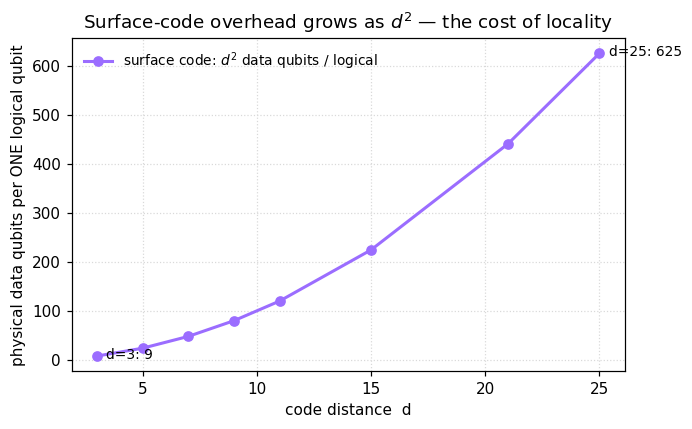

Exact (rotated surface code): one logical qubit costs d^2 data qubits + ~d^2 ancillas.
At d=25 that's 625 data qubits for a SINGLE logical qubit - before ancillas.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

# Surface-code data-qubit overhead vs distance (structural, exact for the rotated code)
dists = np.array([3, 5, 7, 9, 11, 15, 21, 25])
data_qubits = dists**2  # rotated surface code: d^2 data qubits per logical qubit

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(dists, data_qubits, "o-", color="#9b6dff", lw=2, label="surface code: $d^2$ data qubits / logical")
for d, n in zip(dists, data_qubits):
    if d in (3, 25): ax.annotate(f"d={d}: {n}", (d, n), textcoords="offset points", xytext=(6, -2), fontsize=9)
ax.set_xlabel("code distance  d"); ax.set_ylabel("physical data qubits per ONE logical qubit")
ax.set_title("Surface-code overhead grows as $d^2$ - the cost of locality")
ax.grid(True, ls=":", color="0.85"); ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("Exact (rotated surface code): one logical qubit costs d^2 data qubits + ~d^2 ancillas.")
print("At d=25 that's 625 data qubits for a SINGLE logical qubit - before ancillas.")

---
## 2 · qLDPC codes, and the bivariate-bicycle idea

A **quantum low-density parity-check (qLDPC)** code keeps the good property that every check involves only a *few* qubits (low density / bounded weight), but **drops the requirement that those qubits be geometric neighbors on a 2D grid.** By allowing a small number of *longer-range* connections, qLDPC codes can encode **many logical qubits in far fewer physical qubits** than the surface code.

IBM's **bivariate-bicycle (BB)** codes are the headline example. The construction (Bravyi et al., *Nature* 2024) builds the X- and Z-check matrices from **two bivariate polynomials** over a cyclic group $\mathbb{Z}_r \times \mathbb{Z}_s$ - hence "bivariate," and "bicycle" because the check matrix is built from two circulant blocks. The key structural facts, all citable:

- **Every check has weight 6** (touches exactly 6 qubits) - still low-density, like the surface code's weight-4 checks.
- **Each qubit connects to 6 others**, and the connectivity graph **decomposes into two planar (degree-3) layers** - so it's *almost* 2D-local, just with a couple of longer-range links. That "almost local" is what makes it buildable on real hardware.
- The flagship **[[144, 12, 12]] "gross code"**: **144 data qubits + 144 ancilla = 288 physical qubits**, encoding **12 logical qubits**, at **distance 12**.

Compare the overhead. A surface code at distance 12 protects **one** logical qubit with ~$12^2 = 144$ data qubits. The gross code protects **twelve** logical qubits at the same distance with the same 144 data qubits - a **~10-12× improvement in encoding rate**, which is the figure IBM reports.

In [2]:
# Encoding-rate comparison (sourced parameters):
#   surface code at distance d: [[~d^2, 1, d]]  -> 1 logical per d^2 data qubits
#   gross BB code:              [[144, 12, 12]]  -> 12 logical per 144 data qubits
def surface_params(d): return dict(n=d*d, k=1, d=d, rate=1/(d*d))
gross = dict(n=144, k=12, d=12, rate=12/144)

sc12 = surface_params(12)
print("Surface code, distance 12:   [[%d, %d, %d]]  encoding rate k/n = %.4f"
      % (sc12["n"], sc12["k"], sc12["d"], sc12["rate"]))
print("Gross BB code (IBM, Nature): [[%d, %d, %d]]  encoding rate k/n = %.4f"
      % (gross["n"], gross["k"], gross["d"], gross["rate"]))
print("\nSame data-qubit count (144), same distance (12):")
print("  surface code protects %d logical qubit;  gross code protects %d." % (sc12["k"], gross["k"]))
print("  -> ~%.0fx higher encoding rate for the BB code (IBM reports ~10x overhead reduction)."
      % (gross["rate"]/sc12["rate"]))

Surface code, distance 12:   [[144, 1, 12]]  encoding rate k/n = 0.0069
Gross BB code (IBM, Nature): [[144, 12, 12]]  encoding rate k/n = 0.0833

Same data-qubit count (144), same distance (12):
  surface code protects 1 logical qubit;  gross code protects 12.
  -> ~12x higher encoding rate for the BB code (IBM reports ~10x overhead reduction).


---
## 3 · Seeing the difference: Tanner graphs

The clearest way to *feel* why these codes differ is to look at their **Tanner graphs** - the bipartite graph linking data qubits to the checks that touch them.

- **Surface code:** checks are **geometrically local**. Every check links to ≤4 data qubits that are its immediate neighbors on the grid. Draw it and you get a clean, planar, grid-like graph - no long edges.
- **Bivariate-bicycle code:** checks have weight 6 and the connectivity is **two planar layers plus a few longer-range links**. Draw it and you see mostly-local structure *with* some edges that jump across the layout - exactly the "almost local" character that buys the higher rate.

Below we draw the **real** surface-code Tanner graph (from the code we built in Notebook 1), then a **small, explicitly-simplified** bicycle-style graph built from two circulant shifts to illustrate the *contrast in connectivity*.

> ⚠️ **What's simplified:** the right-hand graph is a *toy* circulant/bicycle structure for visual intuition only - it is **not** the actual [[144,12,12]] code, its distance is not computed, and it is **not** a validated quantum code. It exists to show "local grid" vs "circulant with wraparound links." A real BB code requires choosing the two polynomials so the X and Z checks commute (the CSS condition) and verifying the distance - see the honesty note in Section 4.

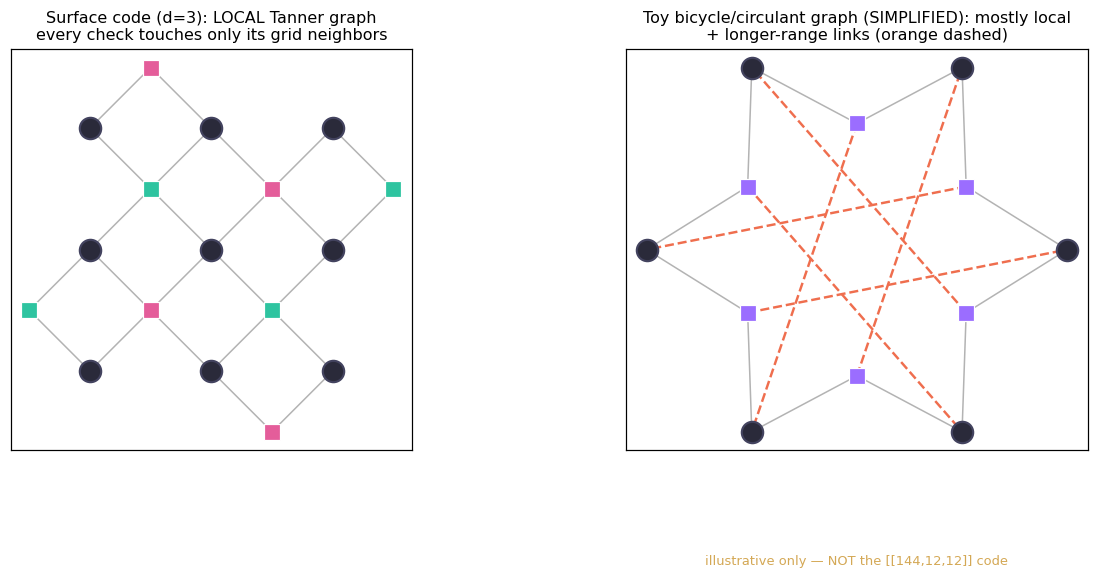

Left: real surface-code Tanner graph (all edges short/local).
Right: toy circulant structure - note the orange long-range edges qLDPC codes add.


In [3]:
# ---- real surface-code Tanner graph (reuse Notebook 1's build, condensed) ----
def build_data_qubits(d): return [(r,c) for r in range(d) for c in range(d)]
def build_stabilizers(d):
    stabs=[]
    for R in range(-1,d):
        for C in range(-1,d):
            t="Z" if (R+C)%2==0 else "X"
            cand=[(rr,cc) for (rr,cc) in [(R,C),(R,C+1),(R+1,C),(R+1,C+1)] if 0<=rr<d and 0<=cc<d]
            if not cand: continue
            tb=(R==-1 or R==d-1); lr=(C==-1 or C==d-1)
            if len(cand)==2:
                if t=="Z" and not lr: continue
                if t=="X" and not tb: continue
            if len(cand) not in (2,4): continue
            stabs.append({"type":t,"center":(C+0.5,R+0.5),"data":cand})
    return stabs

d=3
data=build_data_qubits(d); stabs=build_stabilizers(d)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# LEFT: surface code Tanner graph, drawn on its real geometry
ax=axes[0]
for s in stabs:
    cx,cy=s["center"]
    for (r,c) in s["data"]:
        ax.plot([c,cx],[r,cy], color="0.7", lw=1, zorder=1)
for (r,c) in data:
    ax.plot(c,r,"o",ms=14,color="#2a2a3a",mec="#43435f",mew=1.4,zorder=3)
for s in stabs:
    cx,cy=s["center"]
    col="#2ec4a0" if s["type"]=="Z" else "#e45d9a"
    ax.plot(cx,cy,"s",ms=11,color=col,mec="white",mew=0.8,zorder=3)
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_title("Surface code (d=3): LOCAL Tanner graph\nevery check touches only its grid neighbors", fontsize=10.5)
ax.set_xticks([]); ax.set_yticks([])

# RIGHT: toy bicycle/circulant Tanner graph (SIMPLIFIED, for contrast only)
ax=axes[1]
L=6  # toy ring size
theta=np.linspace(0,2*np.pi,L,endpoint=False)
qx,qy=np.cos(theta),np.sin(theta)              # data qubits on a ring
cx_,cy_=0.6*np.cos(theta+np.pi/L),0.6*np.sin(theta+np.pi/L)  # checks inside
# two circulant shifts: each check i connects to data i, i+1 (local) and i+3 (long-range wrap)
shifts=[0,1,3]
for i in range(L):
    for sh in shifts:
        j=(i+sh)%L
        long_range = sh==3
        ax.plot([cx_[i],qx[j]],[cy_[i],qy[j]],
                color=("#ef6e4e" if long_range else "0.7"),
                lw=(1.6 if long_range else 1),
                ls=("--" if long_range else "-"), zorder=1)
for i in range(L):
    ax.plot(qx[i],qy[i],"o",ms=14,color="#2a2a3a",mec="#43435f",mew=1.4,zorder=3)
    ax.plot(cx_[i],cy_[i],"s",ms=11,color="#9b6dff",mec="white",mew=0.8,zorder=3)
ax.set_aspect("equal")
ax.set_title("Toy bicycle/circulant graph (SIMPLIFIED): mostly local\n+ longer-range links (orange dashed)", fontsize=10.5)
ax.set_xticks([]); ax.set_yticks([])
ax.text(0,-1.5,"illustrative only - NOT the [[144,12,12]] code", ha="center", fontsize=8.5, color="#d4a855")

plt.tight_layout(); plt.show()
print("Left: real surface-code Tanner graph (all edges short/local).")
print("Right: toy circulant structure - note the orange long-range edges qLDPC codes add.")

The contrast is the whole point. The surface code's graph is **all short edges** - beautifully local, but that locality is exactly what forces the $d^2$ overhead. The bicycle-style graph keeps *most* edges local but adds a **few long-range links** (orange, dashed), and those few non-local connections are what let it pack many more logical qubits into the same number of physical ones.

The price: those long-range links are **harder to build** in hardware (you can't just wire nearest neighbors), and they make **decoding harder** - which connects directly to why learned/advanced decoders (Notebook 5) matter for these codes.

---
## 4 · Honesty: what's real, what's simplified, what a real implementation needs

Keeping faith with the rest of this project:

**What is real and sourced in this notebook:**
- The surface-code $d^2$ overhead scaling (exact for the rotated code we built).
- The [[144,12,12]] gross-code parameters: 144 data + 144 ancilla qubits, 12 logical qubits, distance 12 (Bravyi et al., *Nature* 2024).
- Weight-6 checks, degree-6 connectivity decomposing into two planar layers (Error Correction Zoo / the Nature paper).
- The ~10× encoding-rate / overhead improvement vs the surface code (IBM's reported figure).

**What is explicitly simplified / illustrative:**
- The "~1,000 physical qubits per logical qubit" figure for running algorithms is the commonly-cited *scale*, not a single sourced constant - labeled illustrative.
- The right-hand Tanner graph is a **toy circulant structure for visual contrast only.** It is not the gross code, its checks were not verified to commute, and its distance was not computed.

**What a real bivariate-bicycle implementation would require (and we did NOT do):**
- Choosing the two bivariate polynomials so the X- and Z-check matrices **commute** (the CSS condition $H_X H_Z^T = 0$).
- **Computing the code distance** (a hard combinatorial problem) to confirm it's actually [[144,12,12]].
- A real **qLDPC decoder** - typically **BP + ordered-statistics decoding (BP-OSD)** or similar - because, as Notebook 5 showed, plain BP alone is not enough. We did **not** build or benchmark such a decoder here, and we make no claim to have one.

---
## 5 · Wrap-up - and the bridge to the research connection

The surface code is the workhorse of today's experiments, but its $d^2$ overhead is a wall at scale. **qLDPC codes - bivariate-bicycle codes in particular - trade a little locality for a ~10× cut in qubit overhead**, which is why IBM has put them at the center of its fault-tolerance roadmap. The cost is harder hardware connectivity and harder decoding - and *harder decoding* is exactly where learned decoders (Notebook 5) and this project's research thread come in.

- **→ Notebook 5 - Learned decoding (GNNs)** - the decoder side of the frontier.
- **→ [QEC Explorer · research connection](research.html)** - how this project's threads (surface-code intuition, real decoders, the threshold, learned decoding, and qLDPC) connect to current research, with the arXiv manuscript linked when available.
- **→ [Module 1 (live)](https://github.com/kondshk/QEC-Explorer)** · **[Module 2 (live)](https://github.com/kondshk/QEC-Explorer)** · **[Module 3 (live)](https://github.com/kondshk/QEC-Explorer)** - the interactive tools the math in these notebooks powers.

You've now seen both halves of the scaling problem - **better codes** (this notebook) and **better decoders** (Notebook 5). That's the frontier.

---
### Citations
- S. Bravyi, A. Cross, J. Gambetta, D. Maslov, P. Rall, T. Yoder, **"High-threshold and low-overhead fault-tolerant quantum memory,"** *Nature* 627, 778-782 (2024). The bivariate-bicycle codes and the [[144,12,12]] gross code.
- The Error Correction Zoo, **"Bivariate bicycle (BB) code"** and **"[[144,12,12]] gross code"** entries (errorcorrectionzoo.org) - weight-6 checks, degree-3 planar-layer connectivity, code parameters.
- IBM Quantum, **"Landmark IBM error correction paper on Nature cover"** and IBM's large-scale FTQC roadmap blog (ibm.com/quantum/blog) - the ~10× overhead-reduction figure.
- Surface-code $d^2$ overhead is structural to the rotated surface code built in Notebook 1; the "~1000 physical:1 logical" running-algorithm figure is illustrative of commonly-cited scales, not a single sourced constant.